In [1]:
import json
import argparse
import torch
from torch import nn
import wandb
from matplotlib import pyplot as plt
from src.data_loader import get_data_loaders
from src.loss import DifferentiableWeightedRadialFrequencyLoss
from src.model_diffusion import DiffusionModel
from src.model import Unet
from src.trainer import train_diffusion_model, train_diffusion_model_multisteps
from src.utils import count_parameters, compute_radial_psd_error
from src.diffusion_utils import predict_start_from_noise, ddim_x0_estimate
from torch import optim

device = 'cuda'

In [2]:
from sda.mcs import KolmogorovFlow

%env CUDA_DEVICE_ORDER=PCI_BUS_ID
%env CUDA_VISIBLE_DEVICES=5

env: CUDA_DEVICE_ORDER=PCI_BUS_ID
env: CUDA_VISIBLE_DEVICES=5


In [15]:
import torch

def run_model(model, x):
    """Wrapper for forward pass."""
    if isinstance(model, Unet):
        return model(x, time=None)
    else:
        return model(x)
    
class CombModel(nn.Module):
    def __init__(self, models, coefs):
        super().__init__()
        self.models = models
        self.coefs = coefs

    def forward(self, x):
        avg = torch.zeros(x.shape).to(x.device)
        for m, coef in zip(self.models, self.coefs):
            avg += run_model(m, x)*coef
        return avg


def evaluate_models(models, m_eval, traj_loader, device, rollout_steps=30, with_meta_eval=False):
    """
    Compare:
    - plain model rollouts vs. m_eval rollouts (eval_distances)
    - plain model rollouts vs. model(eval(model)) rollouts (meta_distances)

    Args:
        models (dict): { "name": model } dictionary of models to evaluate
        m_eval (nn.Module): evaluator model
        traj_loader (DataLoader): trajectory loader
        device (torch.device): device to run on
        rollout_steps (int): number of rollout steps

    Returns:
        dict with:
            predictions[name]: list of model rollout tensors
            meta_eval[name]: list of model(eval(model)) rollout tensors
            eval_distances[name]: list of distances vs m_eval
            meta_distances[name]: list of distances vs meta trajectory
    """
    # Put all models in eval mode
    for model in list(models.values()) + [m_eval]:
        model.eval()

    if with_meta_eval :
        meta_eval = {name: [] for name in models}
        meta_distances = {name: [] for name in models}
        meta_preds = {name: [] for name in models}
    
    eval_distances = {name: [] for name in models}

    with torch.no_grad():
        sample = next(iter(traj_loader))

        data = sample["data"].to(device)
        print("Input shape:", data.shape)

        conditioning_frame = data[:, 0]

        # Initialize plain and meta trajectories
        preds = {name: run_model(model, conditioning_frame) for name, model in models.items()}
        predictions = {name: [preds[name]] for name, model in models.items()}
        

        # Store step 0
        for name, model in models.items():    
            pred_eval = run_model(m_eval, conditioning_frame)
            if with_meta_eval:
                meta_preds[name].append(pred_eval)
            eval_distances[name].append(torch.mean((pred_eval - preds[name]) ** 2))

        # Rollout
        for t in range(rollout_steps):
            for name, model in models.items():

                eval_pred_on_model = run_model(m_eval, preds[name])

                if with_meta_eval:
                    model_pred_on_eval = run_model(model, meta_preds[name])
                    meta_preds[name] = eval_pred_on_model
                
                # plain model step
                preds[name] = run_model(model, preds[name])
                predictions[name].append(preds[name])
                
                # distance vs m_eval
                eval_distances[name].append(torch.mean((eval_pred_on_model - preds[name]) ** 2))
                # distance vs meta trajectory
                if with_meta_eval:
                    meta_distances[name].append(torch.mean((model_pred_on_eval - preds[name]) ** 2))

    if with_meta_eval:
        return {
            "predictions": preds,
            "meta_eval": meta_eval,
            "eval_distances": eval_distances,
            "meta_distances": meta_distances,
        }
    return {"predictions": predictions,
            "eval_distances": eval_distances,
            "data": data}


In [16]:
data_params = {
        "data_path": "/mnt/SSD2/constantin/sda/data",
        "dataset_name": "KolmogorovFlow",
        "resolution": 64,
        "sequence_length": [2, 1],
        "trajectory_sequence_length": [64, 1],
        "frames_per_time_step": 1,
        "limit_trajectories_train": 819,
        "limit_trajectories_val": 102,
        "batch_size": 100
    }

train_loader, val_loader, traj_loader = get_data_loaders(data_params)

aaaa 819
aaaa 102
aaaa 102


In [79]:
m_eval = Unet(
            dim=64,
            channels= 2,
            dim_mults=(1,1,1),
            use_convnext=True,
            convnext_mult=1,
            with_time_emb=False)

checkpoint = torch.load("/mnt/SSD2/constantin/autoreg-pde-diffusion-old/runs/2D_Kolmo_rozet_upsampled/res_64_ts_1_dim_64_framesPerTs_1_unet-periodicconv-m2_13/Model.pth", map_location=torch.device('cpu'))['stateDictDecoder']
m_eval.load_state_dict(checkpoint)

m_eval.to(device)

m_eval_2 = Unet(
            dim=64,
            channels= 2,
            dim_mults=(1,1,1),
            use_convnext=True,
            convnext_mult=1,
            with_time_emb=False)

checkpoint = torch.load("/mnt/SSD2/constantin/autoreg-pde-diffusion-old/runs/2D_Kolmo_rozet_upsampled/res_64_ts_1_dim_64_framesPerTs_1_unet-periodicconv-m2_13/Model_E1200.pth", map_location=torch.device('cpu'))['stateDictDecoder']
m_eval_2.load_state_dict(checkpoint)

m_eval_2.to(device)

m_eval_3 = Unet(
            dim=64,
            channels= 2,
            dim_mults=(1,1,1),
            use_convnext=True,
            convnext_mult=1,
            with_time_emb=False)

checkpoint = torch.load("/mnt/SSD2/constantin/autoreg-pde-diffusion-old/runs/2D_Kolmo_rozet_upsampled/res_64_ts_1_dim_64_framesPerTs_1_unet-periodicconv-m2_13/Model_E3500.pth", map_location=torch.device('cpu'))['stateDictDecoder']
m_eval_3.load_state_dict(checkpoint)

m_eval_3.to(device)

m_eval_4 = Unet(
            dim=64,
            channels= 2,
            dim_mults=(1,1,1),
            use_convnext=True,
            convnext_mult=1,
            with_time_emb=False)

checkpoint = torch.load("/mnt/SSD2/constantin/autoreg-pde-diffusion-old/runs/2D_Kolmo_rozet_upsampled/res_64_ts_1_dim_64_framesPerTs_1_unet-periodicconv-m2_13/Model_E3000.pth", map_location=torch.device('cpu'))['stateDictDecoder']
m_eval_4.load_state_dict(checkpoint)

m_eval_4.to(device)

m1 =  DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "quadratic",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddim",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_102/best_model.pth')
m1.load_state_dict(checkpoint)

m2 =  DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "quadratic",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddim",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_108/best_model.pth')
m2.load_state_dict(checkpoint)

<All keys matched successfully>

In [144]:
results = evaluate_models({"unet2": m_eval, "unet1": m_eval_2, "diff1":m1}, m_eval, traj_loader, device, rollout_steps=1)

Input shape: torch.Size([100, 64, 2, 64, 64])


In [150]:
for k in results["eval_distances"].keys():
    print(torch.mean((results["predictions"][k][0] - results["data"][:,1])**2).cpu())

for k in results["eval_distances"].keys():
    print(torch.mean((results["predictions"][k][15] - results["data"][:,16])**2).cpu())

tensor(1.2007e-06)
tensor(2.4994e-06)
tensor(3.5631e-06)


IndexError: list index out of range

In [148]:
import torch
import itertools

# Example: results["predictions"] might have keys like
# {"diffusion-1step": tensor, "diffusion-2steps": tensor, "unet": tensor}

min_error = float("inf")
optimal_ts = None

# Get all prediction tensors
pred_keys = list(results["predictions"].keys())
pred_tensors = [results["predictions"][k][0] for k in pred_keys]

# Define weight search grid
weight_range = torch.linspace(0, 1, 10)

# Iterate over all combinations of weights
for weights in itertools.product(weight_range, repeat=len(pred_tensors)):
    # Compute weighted prediction
    pred = sum(w * t for w, t in zip(weights, pred_tensors))
    
    # Compute error
    error = torch.mean((pred - results["data"][:, 1]) ** 2)
    
    # Track minimum error
    if error < min_error:
        min_error = error
        optimal_ts = weights

print("Minimum error:", min_error.item())
print("Optimal weights:", optimal_ts)

Minimum error: 9.600962584954686e-07
Optimal weights: (tensor(0.6667), tensor(0.2222), tensor(0.1111))


In [142]:
results_avg = evaluate_models({"avg_diffusions" : CombModel([m_eval_2, m1], optimal_ts)}, m_eval, traj_loader, device, rollout_steps=20)

Input shape: torch.Size([100, 64, 2, 64, 64])


In [137]:
for k in results_avg["eval_distances"].keys():
    print(torch.mean((results_avg["predictions"][k][15] - results_avg["data"][:,16])**2).cpu())

tensor(0.0003)


In [105]:
for k in results["eval_distances"].keys():
    print(torch.mean((results["predictions"][k][0] - results["data"][:,1])**2).cpu())

#print(torch.mean(((0.5*results["predictions"]["diffusion-1step"][0] + 0.5*results["predictions"]["diffusion-2steps"][0]) - results["data"][:,1])**2).cpu())

for k in results["eval_distances"].keys():
    print(torch.mean((results["predictions"][k][20] - results["data"][:,21])**2).cpu())

for k in results["eval_distances"].keys():
    #plt.plot(torch.Tensor(results["eval_distances"][k])/results["eval_distances"][k][0].cpu())
    plt.plot(torch.Tensor(results["eval_distances"][k]))

plt.yscale('log')
plt.legend()


tensor(1.2007e-06)
tensor(3.5624e-06)
tensor(3.7056e-06)


IndexError: list index out of range

tensor(0.0023)


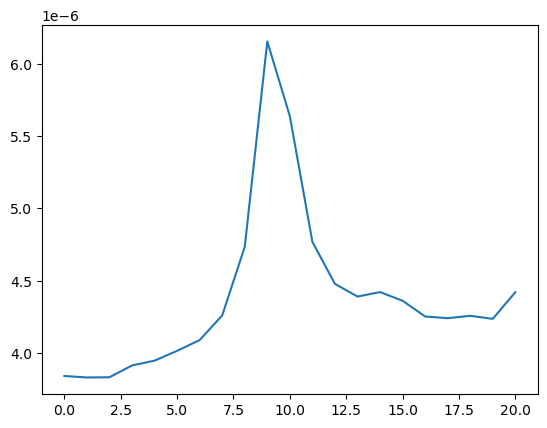

In [39]:
for k in results_avg["eval_distances"].keys():
    print(torch.mean((results_avg["predictions"][k][20] - results_avg["data"][:,21])**2).cpu())

for k in results_avg["eval_distances"].keys():
    #plt.plot(torch.Tensor(results["eval_distances"][k])/results["eval_distances"][k][0].cpu())
    plt.plot(torch.Tensor(results_avg["eval_distances"][k]))

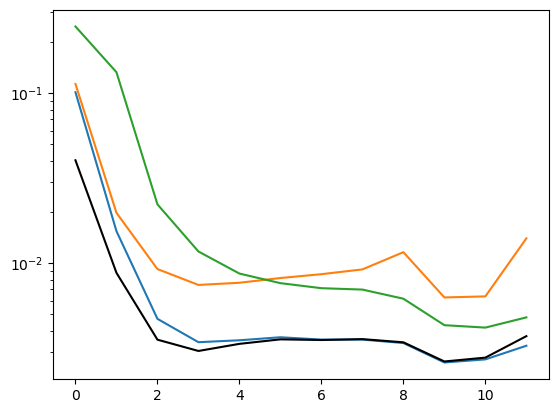

In [149]:
for k in results["eval_distances"].keys():
    plt.plot(compute_radial_psd_error(results["predictions"][k][0], results["data"][:,1]).values())

plt.plot(compute_radial_psd_error(sum(w * t for w, t in zip(optimal_ts, pred_tensors)), results["data"][:,1]).values(), color='black')
plt.yscale('log')